In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
train_df = pd.read_csv('/content/train_1.csv')
test_df = pd.read_csv('/content/test_1.csv')

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)

print("\nTraining labels:")
print(train_df['label'].value_counts())

print("\nTesting labels:")
print(test_df['label'].value_counts())

Training set: (4494, 3)
Testing set: (1284, 3)

Training labels:
label
real    2352
fake    2142
Name: count, dtype: int64

Testing labels:
label
real    672
fake    612
Name: count, dtype: int64


In [3]:
X_train_text = train_df['tweet'].fillna('')
X_test_text = test_df['tweet'].fillna('')

y_train = train_df['label'].map({'fake': 0, 'real': 1})
y_test = test_df['label'].map({'fake': 0, 'real': 1})

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4494
Testing samples: 1284


In [4]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (4494, 5000)
Testing feature shape: (1284, 5000)


In [5]:
base_models = [
    ('logistic_regression', LogisticRegression(
        max_iter=1000,
        random_state=42
    )),

    ('random_forest', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),

    ('svm', LinearSVC(
        random_state=42
    ))
]

In [6]:
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1
)

print(stacking_model)

StackingClassifier(cv=5,
                   estimators=[('logistic_regression',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42)),
                               ('random_forest',
                                RandomForestClassifier(n_estimators=300,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('svm', LinearSVC(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)


In [7]:
stacking_model.fit(X_train, y_train)

print("Stacking ensemble training complete!")

Stacking ensemble training complete!


In [8]:
y_pred = stacking_model.predict(X_test)

print("Predictions complete!")

Predictions complete!


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1 * 100:.2f}%)")

Accuracy:  0.9385 (93.85%)
Precision: 0.9387 (93.87%)
Recall:    0.9385 (93.85%)
F1-Score:  0.9385 (93.85%)


In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Fake', 'Real']
))

              precision    recall  f1-score   support

        Fake       0.93      0.95      0.94       612
        Real       0.95      0.93      0.94       672

    accuracy                           0.94      1284
   macro avg       0.94      0.94      0.94      1284
weighted avg       0.94      0.94      0.94      1284



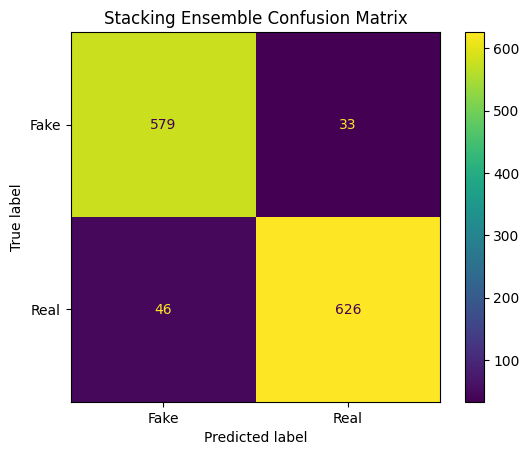

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fake', 'Real']
)

disp.plot()
plt.title('Stacking Ensemble Confusion Matrix')
plt.show()

In [13]:
results = []

individual_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': LinearSVC(
        random_state=42
    )
}

for name, model in individual_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(
            y_test, predictions, average='weighted'
        ),
        'Recall': recall_score(
            y_test, predictions, average='weighted'
        ),
        'F1-Score': f1_score(
            y_test, predictions, average='weighted'
        )
    })

results.append({
    'Model': 'Stacking Ensemble',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.927570,0.927960,0.927570,0.927602
1,Random Forest,0.919003,0.920866,0.919003,0.919042
2,SVM,0.934579,0.934789,0.934579,0.934602
3,Stacking Ensemble,0.938474,0.938712,0.938474,0.938496
